In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
csv_path= r"C:\Users\admin\Desktop\sandeep\Temporal\validation_predictions_ideal.csv"
df = pd.read_csv(csv_path)
df.head()

,GT,Pred,Error,AbsError
0,33.488694,33.487160,-0.001534,0.001534
1,-5.914727,-6.215341,-0.300613,0.300613
2,-38.294301,-38.213860,0.080444,0.080444
3,-19.946196,-19.438337,0.507858,0.507858
4,79.121594,78.739006,-0.382591,0.382591


In [8]:
import numpy as np
errors = df['AbsError'].values
errors = np.array(errors)

mae = np.mean(errors)
rmse = np.sqrt(np.mean(errors**2))
median = np.median(errors)
maximum = np.max(errors)
p95 = np.percentile(errors, 95)

print("="*50)
print("Ideal Dataset Evaluation")
print("="*50)

print(f"Images             : {len(errors)}")
print(f"MAE                : {mae:.4f}°")
print(f"Median Error       : {median:.4f}°")
print(f"RMSE               : {rmse:.4f}°")
print(f"95th Percentile    : {p95:.4f}°")
print(f"Maximum Error      : {maximum:.4f}°")

print("="*50)

Ideal Dataset Evaluation
Images             : 301
MAE                : 0.3885°
Median Error       : 0.3336°
RMSE               : 0.4927°
95th Percentile    : 0.8974°
Maximum Error      : 2.4369°


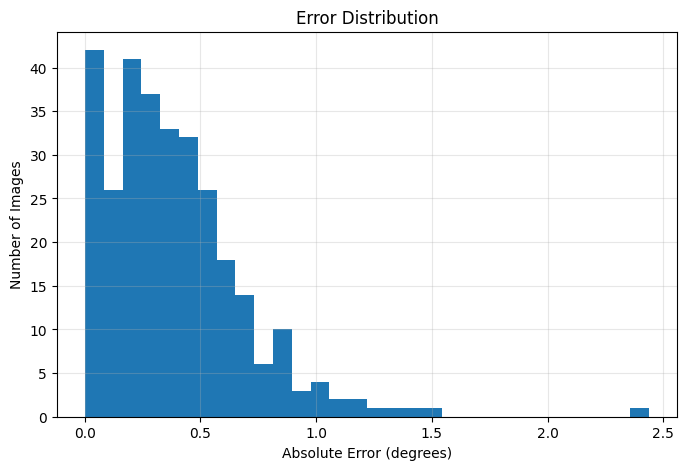

In [9]:
plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.xlabel("Absolute Error (degrees)")
plt.ylabel("Number of Images")
plt.title("Error Distribution")

plt.grid(alpha=0.3)

plt.show()

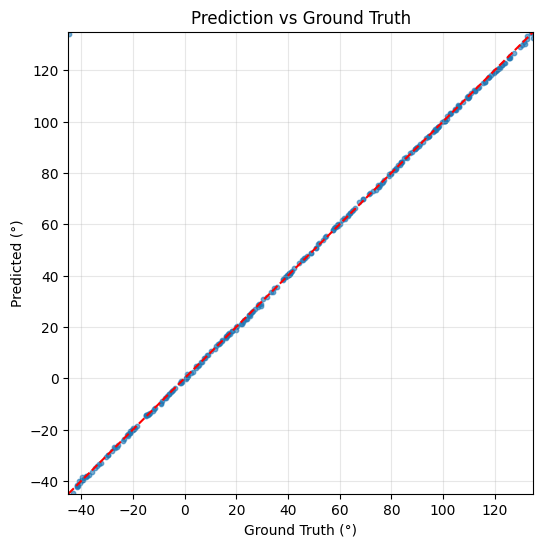

In [12]:
plt.figure(figsize=(6,6))
true_angles = df['GT'].values
pred_angles = df['Pred'].values
plt.scatter(true_angles, pred_angles, s=10, alpha=0.6)

plt.plot([-45,135],[-45,135],'r--')

plt.xlim(-45,135)
plt.ylim(-45,135)

plt.xlabel("Ground Truth (°)")
plt.ylabel("Predicted (°)")
plt.title("Prediction vs Ground Truth")

plt.grid(alpha=0.3)

plt.show()

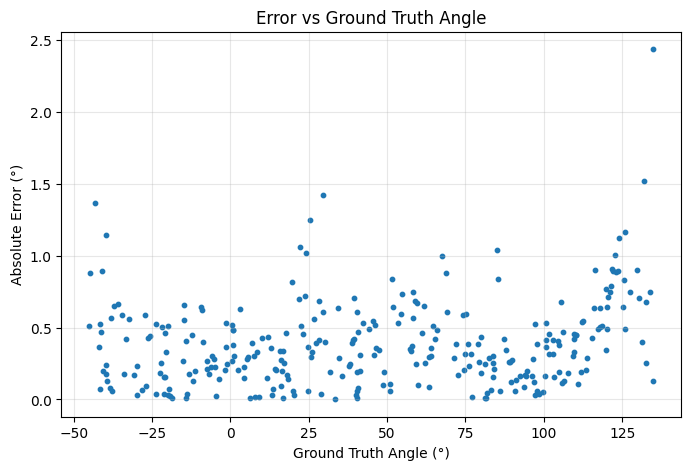

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(true_angles, errors, s=10)

plt.xlabel("Ground Truth Angle (°)")
plt.ylabel("Absolute Error (°)")
plt.title("Error vs Ground Truth Angle")

plt.grid(alpha=0.3)

plt.show()

In [17]:
df=df.sort_values("AbsError", ascending=False)
df.head(10)

,GT,Pred,Error,AbsError
204,134.880322,132.443390,-2.436935,2.436935
242,131.930086,130.411070,-1.519013,1.519013
161,29.652444,28.232782,-1.419663,1.419663
173,-43.334546,-44.701088,-1.366547,1.366547
73,25.448057,24.202883,-1.245178,1.245178
144,125.909178,124.741650,-1.167526,1.167526
225,-39.565437,-38.423800,1.141632,1.141632
266,123.924278,122.800060,-1.124222,1.124222
10,22.223559,21.160412,-1.063149,1.063149
256,84.933569,85.975390,1.041817,1.041817


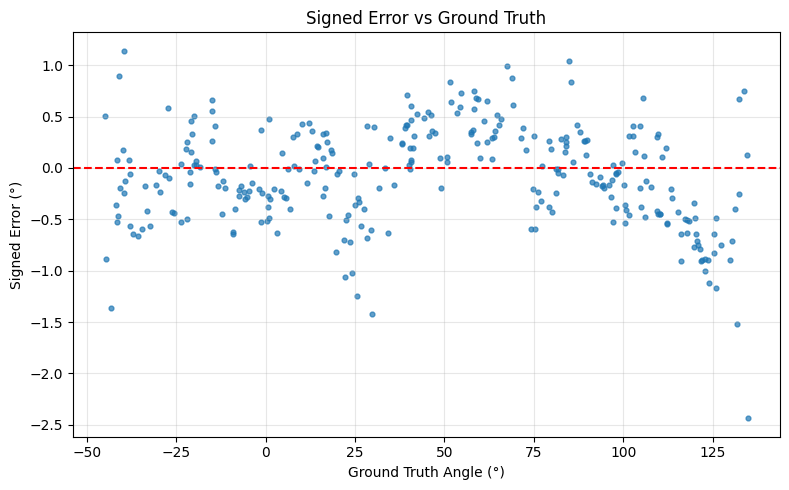

In [18]:
signed_error = ((np.array(pred_angles) - np.array(true_angles) + 90) % 180) - 90

plt.figure(figsize=(8,5))

plt.scatter(
    true_angles,
    signed_error,
    s=12,
    alpha=0.7
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Ground Truth Angle (°)")
plt.ylabel("Signed Error (°)")

plt.title("Signed Error vs Ground Truth")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

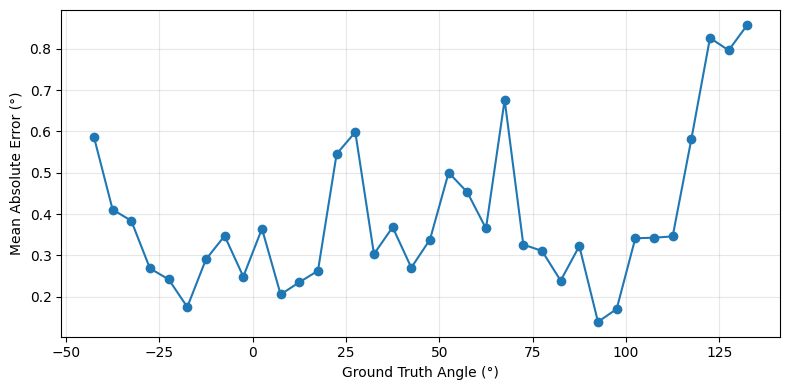

In [19]:
angle_bins = np.arange(-45,136,5)

bin_centers = []
bin_mae = []

for i in range(len(angle_bins)-1):

    mask = (
        (df["GT"] >= angle_bins[i]) &
        (df["GT"] < angle_bins[i+1])
    )

    if mask.sum():

        bin_centers.append(
            (angle_bins[i]+angle_bins[i+1])/2
        )

        bin_mae.append(
            df.loc[mask,"AbsError"].mean()
        )

plt.figure(figsize=(8,4))

plt.plot(
    bin_centers,
    bin_mae,
    '-o'
)

plt.xlabel("Ground Truth Angle (°)")
plt.ylabel("Mean Absolute Error (°)")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

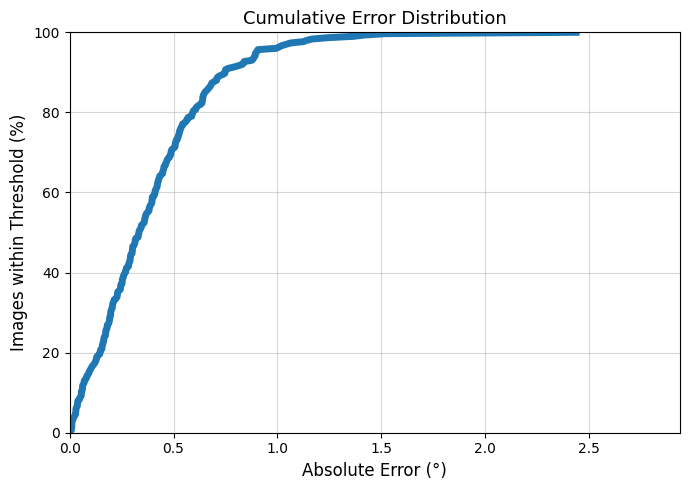

In [22]:
import numpy as np
import matplotlib.pyplot as plt

errors_sorted = np.sort(errors)

cdf = np.arange(1, len(errors_sorted)+1) / len(errors_sorted)

plt.figure(figsize=(7,5))

plt.plot(
    errors_sorted,
    cdf*100,
    linewidth=5
)

plt.xlim(0, max(errors_sorted)+0.5)
plt.ylim(0,100)

plt.xlabel("Absolute Error (°)", fontsize=12)
plt.ylabel("Images within Threshold (%)", fontsize=12)
plt.title("Cumulative Error Distribution", fontsize=13)

plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()

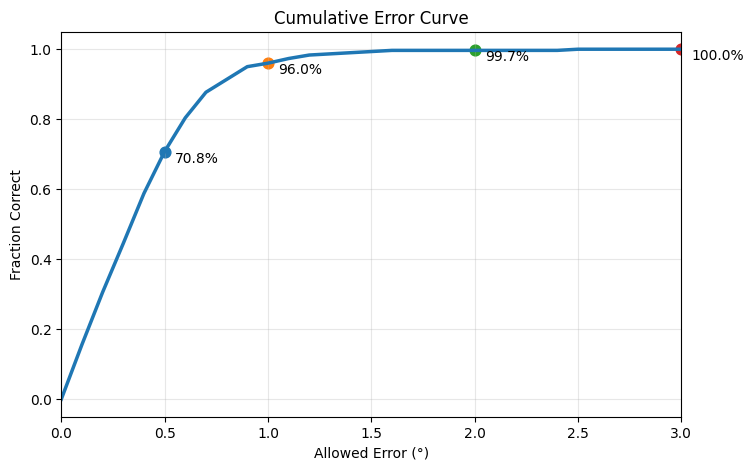

In [25]:
thresholds = np.arange(0,10.1,0.1)

accuracy = [
    np.mean(df["AbsError"] <= t)
    for t in thresholds
]

plt.figure(figsize=(8,5))

plt.plot(thresholds, accuracy, linewidth=2.5)
plt.xlabel("Allowed Error (°)")
plt.xlim(0, 3)
plt.ylabel("Fraction Correct")

plt.title("Cumulative Error Curve")

plt.grid(alpha=0.3)
for t in [0.5, 1, 2, 3]:
    acc = np.mean(df["AbsError"] <= t)
    plt.scatter(t, acc, s=60)
    plt.text(t + 0.05, acc - 0.03, f"{acc*100:.1f}%")
plt.show()